Cell 1: Импортируйте необходимые библиотеки и проверьте устройство

In [17]:

import pandas as pd
import numpy as np
import pywt
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.unicode_minus'] = False 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch 版本: {torch.__version__}")

PyTorch 版本: 2.11.0+cpu


Cell 2: Загрузить набор данных

In [18]:

base_path = r"C:\Users\12894\Desktop\周三实验\lab5"

print("Загрузка набора данных CSV из локального...")
X_train_raw = pd.read_csv(f"{base_path}\\MI-EEG-B9T_train.csv", header=None).values
y_train = pd.read_csv(f"{base_path}\\2class_MI_EEG_train_9.csv", header=None).values.squeeze()

X_test_raw = pd.read_csv(f"{base_path}\\MI-EEG-B9E_test.csv", header=None).values
y_test = pd.read_csv(f"{base_path}\\2class_MI_EEG_test_9.csv", header=None).values.squeeze()

print(f"Размеры функций обучающего набора: {X_train_raw.shape}, размеры этикетки: {y_train.shape}")
print(f"Размеры функций тестового набора: {X_test_raw.shape}, размеры этикетки: {y_test.shape}")

Загрузка набора данных CSV из локального...
Размеры функций обучающего набора: (400, 3000), размеры этикетки: (400,)
Размеры функций тестового набора: (320, 3000), размеры этикетки: (320,)


Cell 3: Определить разработку функций (непрерывное вейвлет-преобразование CWT)

In [19]:
def extract_scalogram(signal, fs=160):
    scales = np.arange(1, 32)
    coef, freqs = pywt.cwt(signal, scales, 'cmor1.5-1.0', sampling_period=1/fs)

    scalogram = np.abs(coef)
    return scalogram


sample_scalo = extract_scalogram(X_train_raw[0])
print(f"Размер двумерного изображения (карты признаков) одной одномерной мозговой волны после вейвлет-преобразования: {sample_scalo.shape}")

Размер двумерного изображения (карты признаков) одной одномерной мозговой волны после вейвлет-преобразования: (31, 3000)


Cell 4: Создание набора данных PyTorch и DataLoader

In [20]:
class EEGImageDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __len__(self):
        return len(self.y)
        
    def __getitem__(self, idx):
        signal = self.X[idx]
        img = extract_scalogram(signal)
        
        img = np.expand_dims(img, axis=0) 
        
        return torch.tensor(img, dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.float32)

batch_size = 32
train_loader = DataLoader(EEGImageDataset(X_train_raw, y_train), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(EEGImageDataset(X_test_raw, y_test), batch_size=batch_size, shuffle=False)

Cell 5: Постройте модель сверточной нейронной сети (CNN).

In [21]:

class MotorImageryCNN(nn.Module):
    def __init__(self):
        super(MotorImageryCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        
        self.adapool = nn.AdaptiveAvgPool2d((8, 8))
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.features(x)
        x = self.adapool(x)
        x = self.classifier(x)
        return x.squeeze()

model = MotorImageryCNN().to(device)
print(model)

MotorImageryCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (adapool): AdaptiveAvgPool2d(output_size=(8, 8))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


Cell 6: Обучите модель и запишите потери

In [22]:
epochs = 25
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_loss_history = []
train_acc_history = []

print("Начните обучение модели и записывайте данные многомерного анализа....")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        predicted = (outputs > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
    
    avg_loss = running_loss / len(train_loader)
    avg_acc = 100 * correct_train / total_train
    
    train_loss_history.append(avg_loss)
    train_acc_history.append(avg_acc)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:02d}/{epochs}] -> Loss: {avg_loss:.4f} | Accuracy: {avg_acc:.2f}%")

print("Обучение завершено и все данные анализа собраны！")

Начните обучение модели и записывайте данные многомерного анализа....
Epoch [01/25] -> Loss: 0.7462 | Accuracy: 51.25%
Epoch [05/25] -> Loss: 0.6523 | Accuracy: 63.00%
Epoch [10/25] -> Loss: 0.6196 | Accuracy: 63.25%
Epoch [15/25] -> Loss: 0.5577 | Accuracy: 70.00%
Epoch [20/25] -> Loss: 0.5381 | Accuracy: 70.75%
Epoch [25/25] -> Loss: 0.5320 | Accuracy: 72.75%
Обучение завершено и все данные анализа собраны！


Cell 7: Cell 7: 模型测试与结果可视化


Окончательная точность классификации тестового набора: 80.94%

Окончательная точность классификации тестового набора: 80.94%



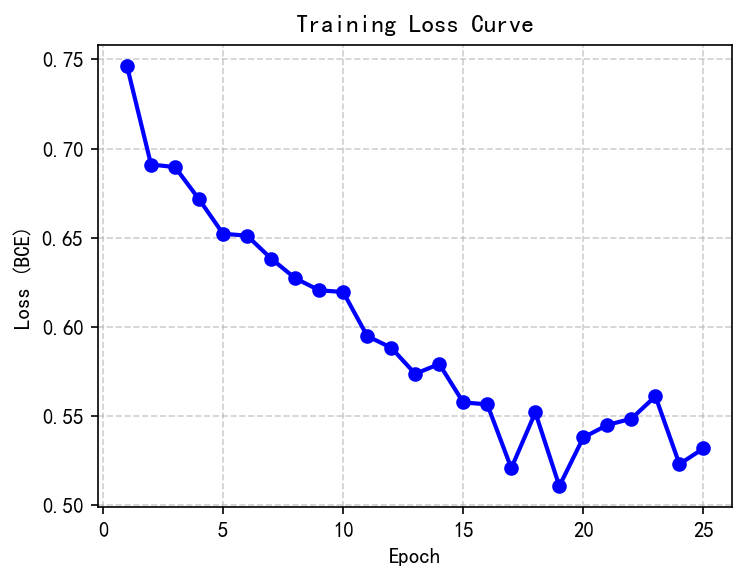

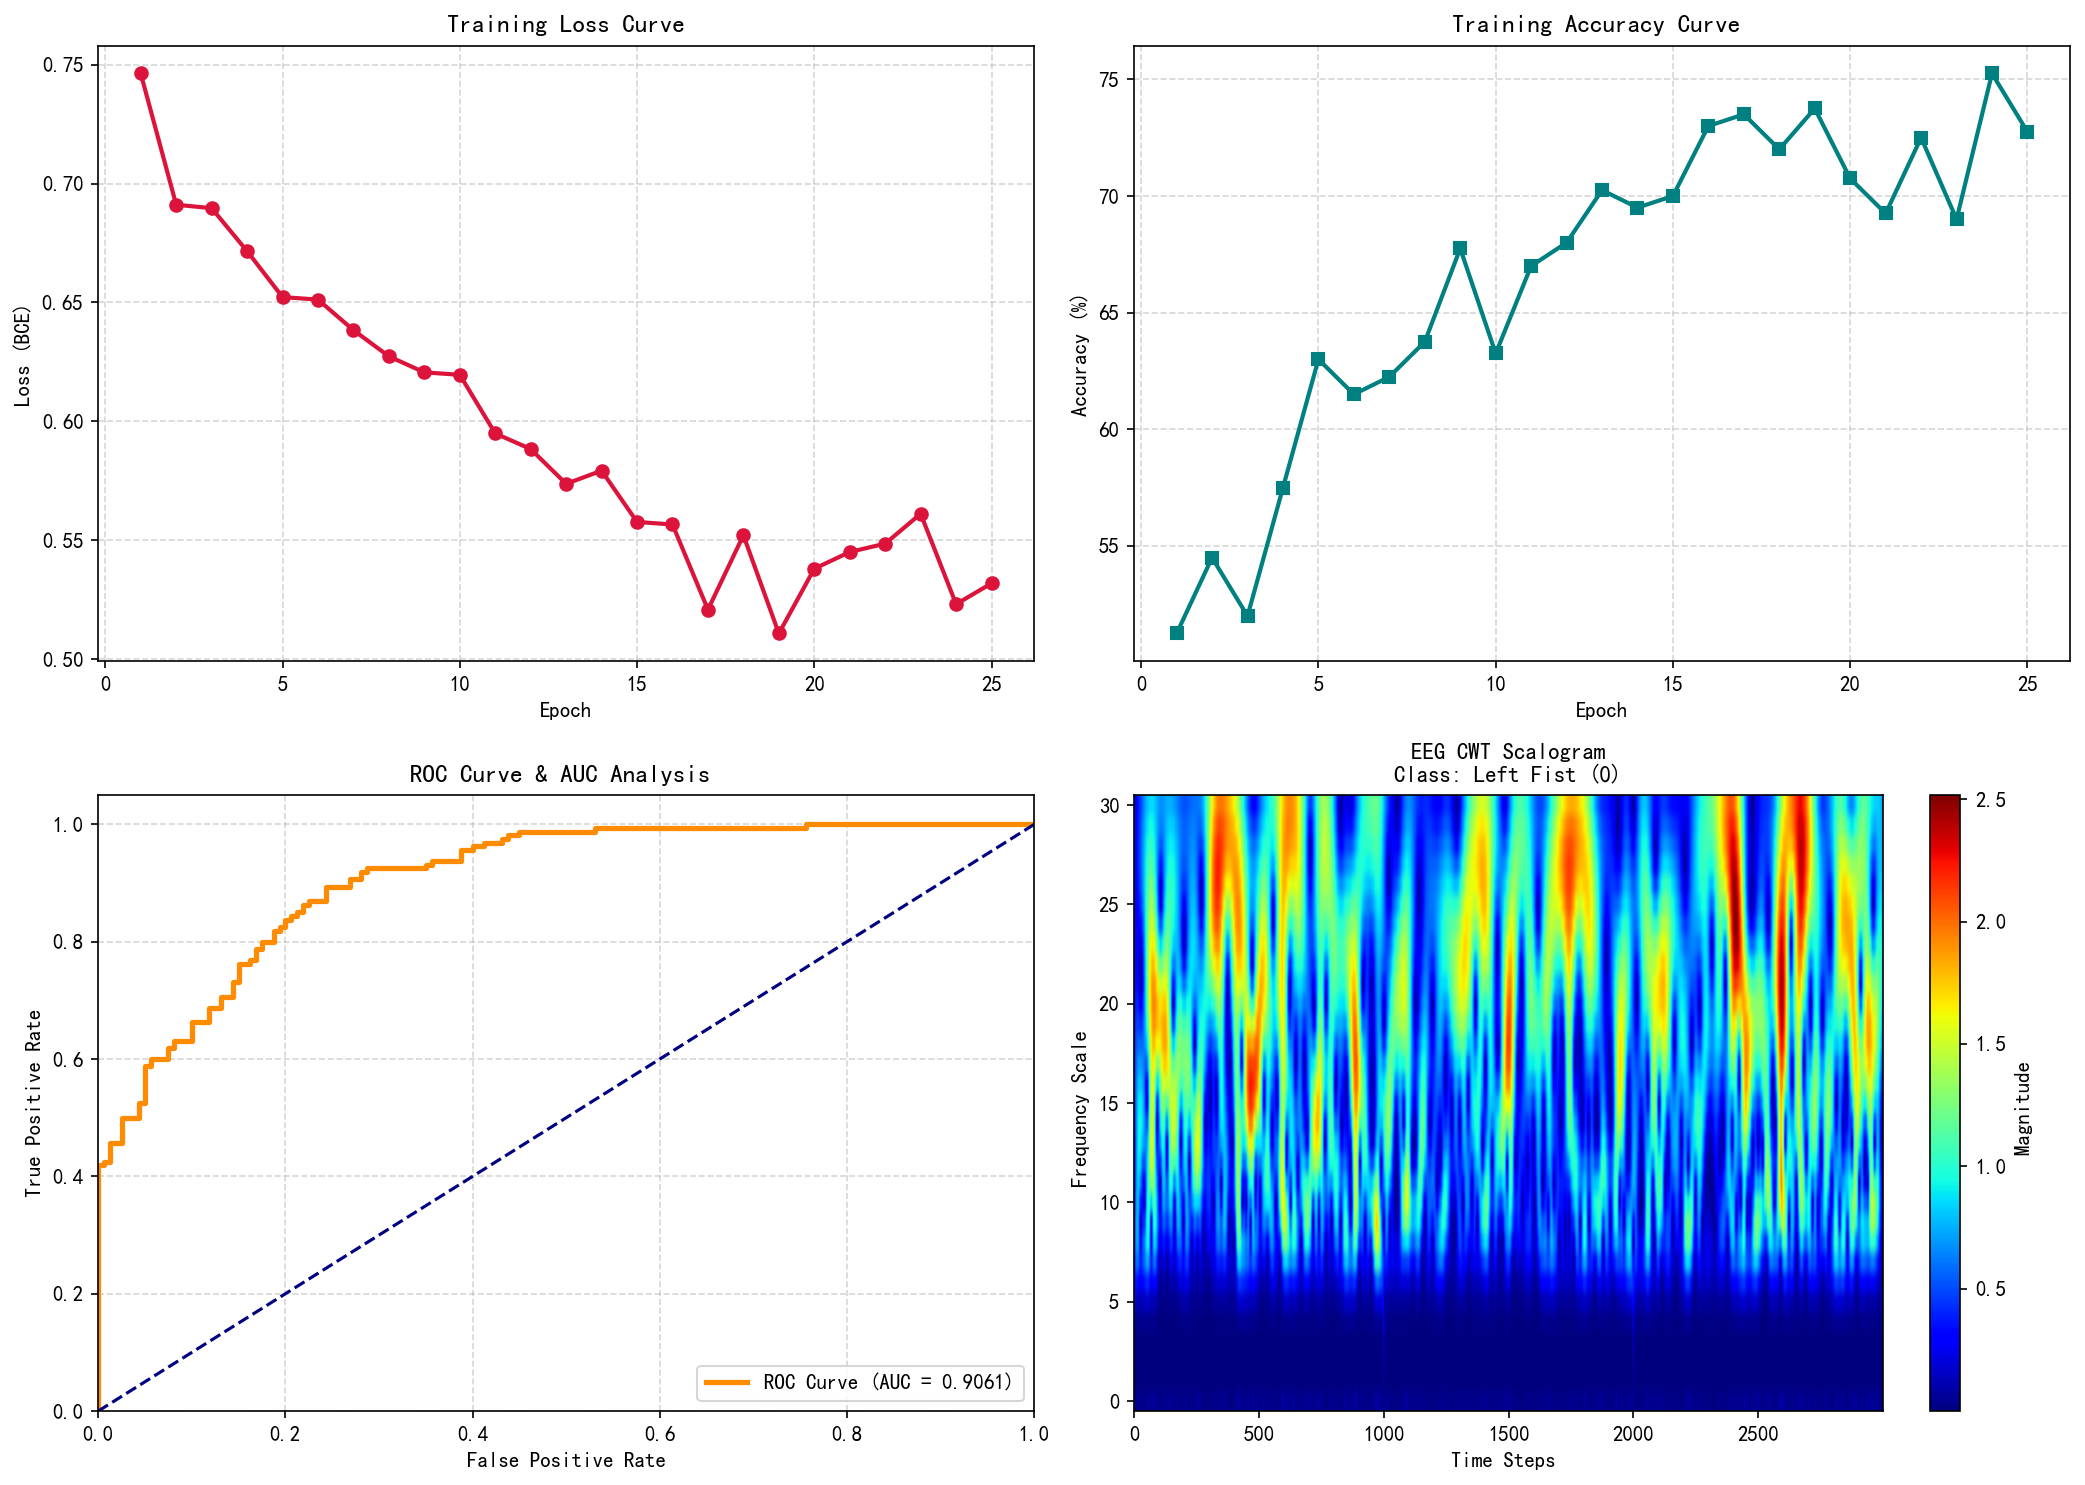

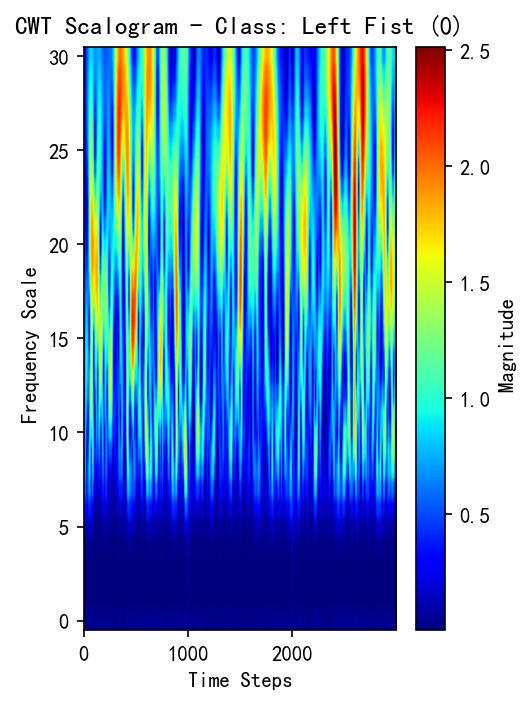

In [24]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Окончательная точность классификации тестового набора: {accuracy:.2f}%\n")

# 2. Нарисуйте кривую потерь при обучении
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_loss_history, marker='o', linestyle='-', color='b', linewidth=2)
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss (BCE)')
plt.grid(True, linestyle='--', alpha=0.6)

from sklearn.metrics import roc_curve, auc

# 1. Соберите предсказанные вероятности и истинные метки на тестовом наборе.
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        
        all_preds.extend(outputs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Рассчитать окончательную точность
final_predicted = (all_preds > 0.5).astype(int)
accuracy = 100 * np.sum(final_predicted == all_labels) / len(all_labels)
print(f"Окончательная точность классификации тестового набора: {accuracy:.2f}%\n")

# Рассчитать кривые ROC и значения AUC
fpr, tpr, _ = roc_curve(all_labels, all_preds)
roc_auc = auc(fpr, tpr)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Рисунок 1. Кривая снижения потерь при обучении
axs[0, 0].plot(range(1, epochs + 1), train_loss_history, marker='o', linestyle='-', color='crimson', linewidth=2)
axs[0, 0].set_title('Training Loss Curve', fontsize=12)
axs[0, 0].set_xlabel('Epoch')
axs[0, 0].set_ylabel('Loss (BCE)')
axs[0, 0].grid(True, linestyle='--', alpha=0.5)

# Рисунок 2. Кривая повышения точности обучения.
axs[0, 1].plot(range(1, epochs + 1), train_acc_history, marker='s', linestyle='-', color='teal', linewidth=2)
axs[0, 1].set_title('Training Accuracy Curve ', fontsize=12)
axs[0, 1].set_xlabel('Epoch')
axs[0, 1].set_ylabel('Accuracy (%)')
axs[0, 1].grid(True, linestyle='--', alpha=0.5)

# Рисунок 3: Золотой стандарт производительности модели – кривая ROC
axs[1, 0].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axs[1, 0].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--') 
axs[1, 0].set_xlim([0.0, 1.0])
axs[1, 0].set_ylim([0.0, 1.05])
axs[1, 0].set_title('ROC Curve & AUC Analysis ', fontsize=12)
axs[1, 0].set_xlabel('False Positive Rate')
axs[1, 0].set_ylabel('True Positive Rate')
axs[1, 0].legend(loc="lower right", fontsize=10)
axs[1, 0].grid(True, linestyle='--', alpha=0.5)

# Рисунок 4: Пример вейвлет-временной диаграммы сигнала ЭЭГ (скалограмма).
sample_idx = 0
sample_scalo = extract_scalogram(X_train_raw[sample_idx])
sample_label = int(y_train[sample_idx])
label_name = "Right Fist (1)" if sample_label == 1 else "Left Fist (0)"

im = axs[1, 1].imshow(sample_scalo, aspect='auto', origin='lower', cmap='jet')
axs[1, 1].set_title(f'EEG CWT Scalogram\nClass: {label_name}', fontsize=11)
axs[1, 1].set_xlabel('Time Steps ')
axs[1, 1].set_ylabel('Frequency Scale ')
fig.colorbar(im, ax=axs[1, 1], label='Magnitude ')

plt.tight_layout()
plt.show()

sample_idx = 0
sample_scalo = extract_scalogram(X_train_raw[sample_idx])
sample_label = int(y_train[sample_idx])
label_name = "Right Fist (1)" if sample_label == 1 else "Left Fist (0)"

plt.subplot(1, 2, 2)

plt.imshow(sample_scalo, aspect='auto', origin='lower', cmap='jet')
plt.colorbar(label='Magnitude ')
plt.title(f'CWT Scalogram - Class: {label_name}')
plt.xlabel('Time Steps')
plt.ylabel('Frequency Scale ')

plt.tight_layout()
plt.show()